Salvato.


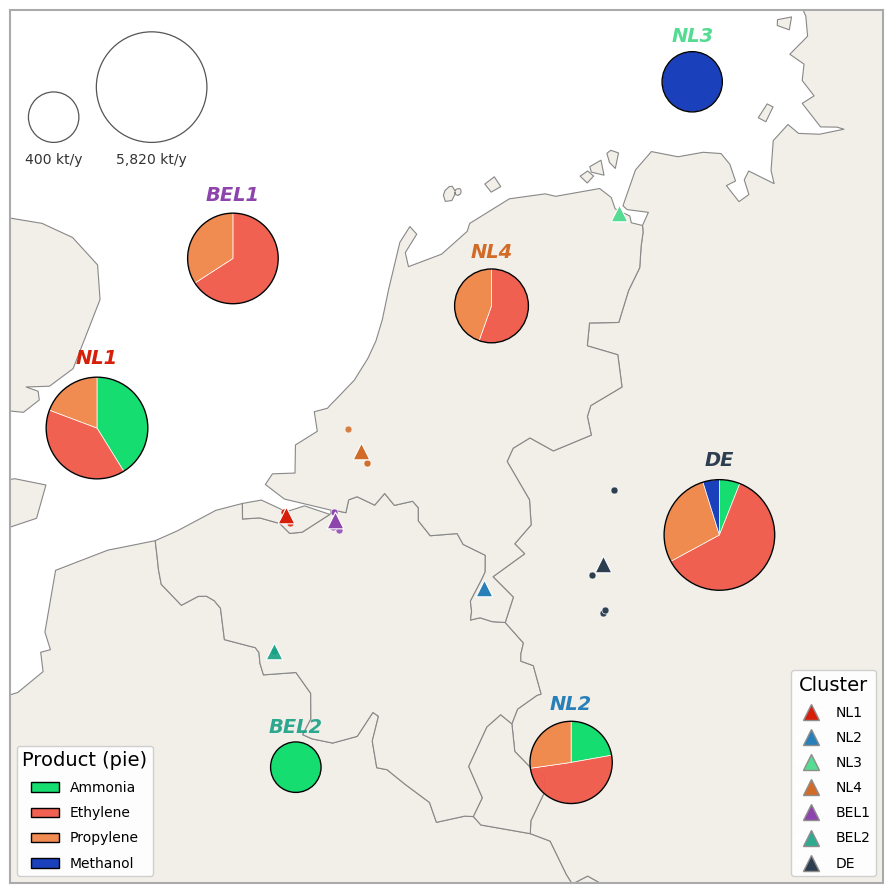

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
import numpy as np

# ── Parametri ────────────────────────────────────────────────────────────────
PLANT_MS    = 5
CENTROID_MS = 120
PIE_R_MIN   = 10_000   # raggio minimo aerogramma (m)
PIE_R_MAX   = 38_000   # raggio massimo aerogramma (m)
XMIN, YMIN, XMAX, YMAX = 3_700_000, 2_900_000, 4_300_000, 3_500_000

PIE_OFFSETS = {
    'NL1':  (-130_000,  60_000),
    'NL2':  (  60_000, -120_000),
    'NL3':  ( 50_000,  90_000),
    'NL4':  (  90_000,  100_000),
    'BEL1': ( -70_000, 180_000),
    'BEL2': (15_000,  -80_000),
    'DE':   ( 80_000,   20_000),
}

CLUSTER_COLORS = {
    'NL1':  "#d61e09", 'NL2':  '#2980b9', 'NL3':  "#55db92",
    'NL4':  "#d16b27", 'BEL1': '#8e44ad', 'BEL2': "#16a084e4", 'DE': '#2c3e50',
}
PRODUCT_COLORS = {
    'Ammonia':   "#15dd6f", 'Ethylene':  "#f05c4cf8",
    'Propylene': "#f0884cf8", 'Methanol':  "#1a40bc",
}
PRODUCTS       = ['Ammonia', 'Ethylene', 'Propylene', 'Methanol']
CAP_COLS       = {p: p.lower() for p in PRODUCTS}
CLUSTERS_ORDER = ['NL1', 'NL2', 'NL3', 'NL4', 'BEL1', 'BEL2', 'DE']

# ── Dati ─────────────────────────────────────────────────────────────────────
plants = pd.read_excel(
    "data/SFI_ALD_Petrochemicals_Sample_EU_NA_Apr_2022.xlsx",
    sheet_name="SFI_ALD_Petrochemicals_EUNA"
)
europe = plants[plants['region'] == 'Europe'].dropna(subset=['latitude','longitude']).copy()

mask_c  = europe['country'].isin(['Netherlands', 'Belgium', 'Luxembourg', 'Germany'])
mask_de = (europe['country'] == 'Germany') & (europe['state'] == 'North Rhine-Westphalia')
europe_filtered = europe[mask_c & ((europe['country'] != 'Germany') | mask_de)].copy()
europe_filtered = europe_filtered[europe_filtered['petrochemical'].isin(PRODUCTS)].copy()

# ── Riepilogo cluster ────────────────────────────────────────────────────────
rows = []
for cl in europe_filtered['Cluster'].unique():
    cd = europe_filtered[europe_filtered['Cluster'] == cl]
    rows.append({
        'cluster':   cl,
        'latitude':  cd['latitude'].mean(),
        'longitude': cd['longitude'].mean(),
        'ammonia':   cd.loc[cd['petrochemical']=='Ammonia',   'capacity'].sum(),
        'ethylene':  cd.loc[cd['petrochemical']=='Ethylene',  'capacity'].sum(),
        'propylene': cd.loc[cd['petrochemical']=='Propylene', 'capacity'].sum(),
        'methanol':  cd.loc[cd['petrochemical']=='Methanol',  'capacity'].sum(),
    })
cluster_df = pd.DataFrame(rows)

# ── total_caps DOPO cluster_df ───────────────────────────────────────────────
total_caps = cluster_df[[v for v in CAP_COLS.values()]].sum(axis=1)
max_cap    = total_caps.max()

# ── GeoDataFrame → EPSG:3035 ─────────────────────────────────────────────────
def to_3035(df, lon='longitude', lat='latitude'):
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[lon], df[lat]),
                           crs='EPSG:4326').to_crs('EPSG:3035')
    gdf['x'] = gdf.geometry.x
    gdf['y'] = gdf.geometry.y
    return gdf

gdf_plants   = to_3035(europe_filtered)
gdf_clusters = to_3035(cluster_df)

# ── Confini NUTS ─────────────────────────────────────────────────────────────
nuts      = gpd.read_file(r'data\NUTS_RG_20M_2016_3035.shp.zip')
countries = nuts[nuts['LEVL_CODE'] == 0].cx[XMIN:XMAX, YMIN:YMAX].copy()

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
countries.plot(ax=ax, color='#f2efe9', edgecolor='#888888', linewidth=0.8)
plt.rcParams['font.size'] = 9
plt.rcParams['font.weight'] = 'normal'

# Layer 1 — puntini impianti
for _, row in gdf_plants.iterrows():
    c = CLUSTER_COLORS.get(row['Cluster'], '#555555')
    ax.plot(row['x'], row['y'], 'o', color=c,
            markersize=PLANT_MS, alpha=0.85, zorder=3,
            markeredgecolor='white', markeredgewidth=0.4)

# Layer 2 — triangoli + leader lines + aerogrammi
for i, crow in gdf_clusters.iterrows():
    cl     = crow['cluster']
    cx, cy = crow['x'], crow['y']
    color  = CLUSTER_COLORS.get(cl, '#333333')
    dx, dy = PIE_OFFSETS.get(cl, (80_000, 80_000))
    px, py = cx + dx, cy + dy

    # Raggio variabile (calcolato una volta sola)
    cap_total = sum(crow[CAP_COLS[p]] for p in PRODUCTS)
    r = PIE_R_MIN + (PIE_R_MAX - PIE_R_MIN) * np.sqrt(cap_total / max_cap)

    # Triangolo al centroide
    ax.scatter(cx, cy, marker='^', s=CENTROID_MS*1.2,
               color=color, edgecolors='white', linewidths=0.8, zorder=6)

    # Leader line → bordo più vicino dell'aerogramma
    # angle    = np.arctan2(cy - py, cx - px)
    # attach_x = px + r * np.cos(angle)
    # attach_y = py + r * np.sin(angle)
    # ax.plot([cx, attach_x], [cy, attach_y],
    #         color=color, linewidth=1.2, linestyle='--', alpha=0.85, zorder=4)

    # Fette aerogramma
    if cap_total == 0:
        continue
    start = 90.0
    for prod in PRODUCTS:
        val = crow[CAP_COLS[prod]]
        if val == 0:
            continue
        sweep = 360.0 * val / cap_total
        ax.add_patch(Wedge(
            center=(px, py), r=r,
            theta1=start - sweep, theta2=start,
            facecolor=PRODUCT_COLORS[prod],
            edgecolor='white', linewidth=0.5, zorder=5
        ))
        start -= sweep

    # Bordo aerogramma
    ax.add_patch(plt.Circle(
        (px, py), r,
        fill=False, edgecolor="#000000", linewidth=1, zorder=6
    ))

    # Etichetta sopra l'aerogramma (usa r, non PIE_RADIUS fisso)
    ax.text(px, py + r * 1.18, cl,
            ha='center', va='bottom',
            fontsize=14, fontweight='bold', color=color, zorder=7, fontstyle='italic')

# ── Legende ──────────────────────────────────────────────────────────────────
prod_handles = [
    mpatches.Patch(facecolor=PRODUCT_COLORS[p], edgecolor='#000000', label=p)
    for p in PRODUCTS
]
clust_handles = [
    Line2D([0],[0], marker='^', color='w',
           markerfacecolor=CLUSTER_COLORS[c], markeredgecolor="#8F8C8C",
           markersize=12, label=c)
    for c in CLUSTERS_ORDER if c in CLUSTER_COLORS
]

leg1 = ax.legend(handles=prod_handles, title='Product (pie)',
                 loc='lower left', fontsize=10, title_fontsize=14,
                 framealpha=0.92, edgecolor='#cccccc', labelspacing=0.8)
ax.legend(handles=clust_handles, title='Cluster',
          loc='lower right', fontsize=10, title_fontsize=14,
          framealpha=0.92, edgecolor='#cccccc', labelspacing=0.8)
ax.add_artist(leg1)

# ── Estetica ─────────────────────────────────────────────────────────────────
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
# ax.set_title('Petrochemical plant clusters — ARRRA region',
#              fontsize=12, fontweight='bold', pad=12)
ax.set_axis_off()

# ── Frame grigio intorno alla figura ────────────────────────────────────────
ax.add_patch(mpatches.Rectangle(
    (0, 0), 1, 1,
    transform=ax.transAxes,
    fill=False, edgecolor='#aaaaaa', linewidth=1.5,
    zorder=10, clip_on=False
))

# ── Legenda dimensioni aerogrammi (alto sinistra) ────────────────────────────
from matplotlib.patches import FancyBboxPatch

LEG_CX  = XMIN + 30_000   # x di riferimento del gruppo
LEG_TOP = YMAX + 10_000 #- 0_000   # y della riga del titolo

cap_min = total_caps.min()
cap_max = total_caps.max()
r_small = PIE_R_MIN + (PIE_R_MAX - PIE_R_MIN) * np.sqrt(cap_min / max_cap)
r_large = PIE_R_MIN + (PIE_R_MAX - PIE_R_MIN) * np.sqrt(cap_max / max_cap)

HORIZ_GAP = 12_000                          # spazio tra i due cerchi
baseline  = LEG_TOP - r_large * 2 - 25_000 # i cerchi poggiano qui

cx_small = LEG_CX
cx_large = LEG_CX + r_small + HORIZ_GAP + r_large

# Box di sfondo (zorder basso, deve stare sotto i cerchi)
pad = 12_000
ax.add_patch(FancyBboxPatch(
    (cx_small - r_small - pad, baseline - 30_000),
    (cx_large + r_large + pad) - (cx_small - r_small - pad),
    (LEG_TOP + 8_000) - (baseline - 30_000),
    boxstyle=f"round,pad={pad*0.3}",
    facecolor='none',
    edgecolor='none',
    linewidth=0,
    alpha=0.0,
    zorder=7,
    transform=ax.transData
))

# Cerchi e etichette
for r, cap, cx in [(r_small, cap_min, cx_small),
                   (r_large, cap_max, cx_large)]:
    cy = baseline + r   # allineati in basso
    ax.add_patch(plt.Circle(
        (cx, cy), r,
        fill=False, edgecolor='#555555', linewidth=0.9,
        linestyle='-', zorder=8
    ))
    ax.text(cx, baseline - 7_000,
            f'{int(cap):,} kt/y',
            ha='center', va='top', fontsize=10, color='#333333', zorder=9)

# Titolo legenda dimensioni
# ax.text((cx_small + cx_large) / 2, LEG_TOP,
#         'Total capacity', ha='center', va='top',
#         fontsize=8.5, fontweight='bold', color='#333333', zorder=9)
plt.tight_layout()
plt.savefig('figure/plants_map_with_clusters.png', dpi=600, bbox_inches='tight')
# plt.savefig('data/plants_map_callout.pdf', bbox_inches='tight')
print("Salvato.")

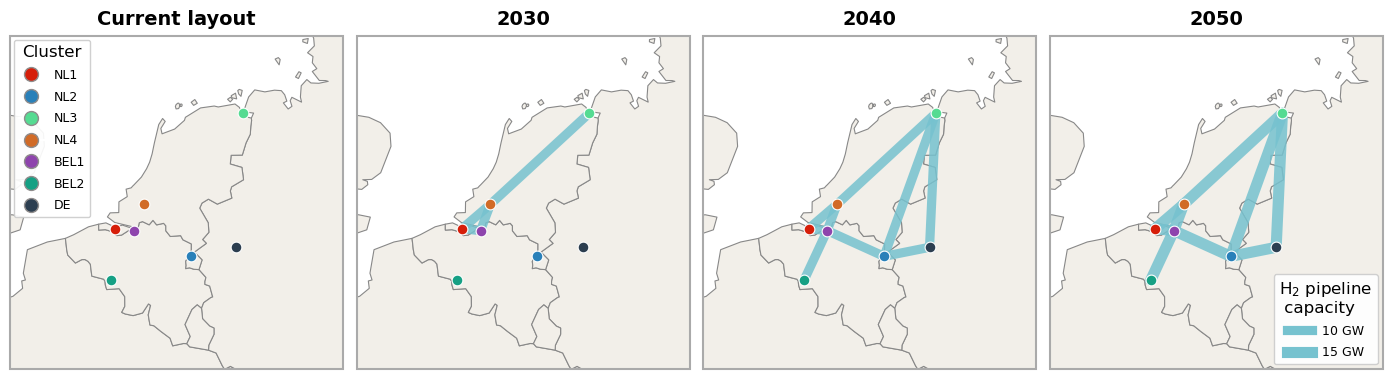

In [72]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Parametri ────────────────────────────────────────────────────────────────
XMIN, YMIN, XMAX, YMAX = 3_700_000, 2_900_000, 4_300_000, 3_500_000
CENTROID_MS = 120

CLUSTER_COLORS = {
    'NL1':  "#d61e09", 'NL2':  '#2980b9', 'NL3':  "#55db92",
    'NL4':  "#d16b27", 'BEL1': '#8e44ad', 'BEL2': "#16a084", 'DE': '#2c3e50',
}
CLUSTERS_ORDER = ['NL1', 'NL2', 'NL3', 'NL4', 'BEL1', 'BEL2', 'DE']

YEARS = [2025, 2030, 2040, 2050]

LINE_WIDTH_MIN = 0.5
LINE_WIDTH_MAX = 8.0
LINE_COLOR     = "#76C2CF"   # arancio-rosso simile al plot di riferimento
LINE_ALPHA     = 0.85

PRODUCTS = ['Ammonia', 'Ethylene', 'Propylene', 'Methanol']

# ── Carica impianti e calcola centroidi cluster (stesso metodo del codice originale) ──
plants = pd.read_excel(
    "data/SFI_ALD_Petrochemicals_Sample_EU_NA_Apr_2022.xlsx",
    sheet_name="SFI_ALD_Petrochemicals_EUNA"
)
europe = plants[plants['region'] == 'Europe'].dropna(subset=['latitude', 'longitude']).copy()
mask_c  = europe['country'].isin(['Netherlands', 'Belgium', 'Luxembourg', 'Germany'])
mask_de = (europe['country'] == 'Germany') & (europe['state'] == 'North Rhine-Westphalia')
europe_filtered = europe[mask_c & ((europe['country'] != 'Germany') | mask_de)].copy()
europe_filtered = europe_filtered[europe_filtered['petrochemical'].isin(PRODUCTS)].copy()

cluster_coords = (
    europe_filtered.groupby('Cluster')[['latitude', 'longitude']].mean().reset_index()
)

# ── Converti centroidi in EPSG:3035 ──────────────────────────────────────────
gdf_clusters = gpd.GeoDataFrame(
    cluster_coords,
    geometry=gpd.points_from_xy(cluster_coords['longitude'], cluster_coords['latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:3035')
gdf_clusters['x'] = gdf_clusters.geometry.x
gdf_clusters['y'] = gdf_clusters.geometry.y

cluster_xy = dict(zip(gdf_clusters['Cluster'], zip(gdf_clusters['x'], gdf_clusters['y'])))


# ── Leggi existing_sizes per un anno ─────────────────────────────────────────
def load_existing_sizes(year):
    path = (
        f"case_studies/base_case_10_dd/{year}/networks/existing/"
        f"hydrogenPipelineOnshore.xlsx"
    )
    df = pd.read_excel(path, sheet_name='existing_sizes', index_col=0)
    return df   # matrice cluster×cluster


# ── Confini NUTS (stesso file dell'altro script) ──────────────────────────────
nuts      = gpd.read_file(r'data/NUTS_RG_20M_2016_3035.shp.zip')
countries = nuts[nuts['LEVL_CODE'] == 0].cx[XMIN:XMAX, YMIN:YMAX].copy()


# ── Calcola spessore linea ────────────────────────────────────────────────────
def line_width(val, max_val):
    if max_val == 0 or val == 0:
        return 0
    return LINE_WIDTH_MIN + (LINE_WIDTH_MAX - LINE_WIDTH_MIN) * np.sqrt(val / max_val)


# ── Raccoglie tutti i valori per normalizzare su tutti gli anni ───────────────
all_values = []
data_by_year = {}
for yr in YEARS:
    try:
        df = load_existing_sizes(yr)
        data_by_year[yr] = df
        # prendi solo il triangolo superiore (matrice simmetrica)
        for i, r in enumerate(df.index):
            for j, c in enumerate(df.columns):
                if j > i:
                    v = df.loc[r, c]
                    if v > 0:
                        all_values.append(v)
    except FileNotFoundError as e:
        print(f"[ATTENZIONE] File non trovato per {yr}: {e}")
        data_by_year[yr] = None

global_max = max(all_values) if all_values else 1


# ── Figura 1×4 ────────────────────────────────────────────────────────────────
plt.rcParams['font.size'] = 9
plt.rcParams['font.weight'] = 'normal'

fig, axes = plt.subplots(1, 4, figsize=(14, 14))
axes_flat = axes.flatten()

for idx, yr in enumerate(YEARS):
    ax = axes_flat[idx]
    df = data_by_year.get(yr)

    # Mappa di sfondo
    countries.plot(ax=ax, color='#f2efe9', edgecolor='#888888', linewidth=0.8)

    if df is not None:
        clusters_in_data = [c for c in df.index if c in cluster_xy]

        # ── Linee pipeline ────────────────────────────────────────────────────
        drawn_pairs = set()
        for r in clusters_in_data:
            for c in df.columns:
                if c not in cluster_xy:
                    continue
                if (r, c) in drawn_pairs or (c, r) in drawn_pairs:
                    continue
                val = df.loc[r, c]
                if val <= 0:
                    continue
                drawn_pairs.add((r, c))
                x0, y0 = cluster_xy[r]
                x1, y1 = cluster_xy[c]
                lw = line_width(val, global_max)
                ax.plot(
                    [x0, x1], [y0, y1],
                    color=LINE_COLOR, linewidth=lw,
                    alpha=LINE_ALPHA, solid_capstyle='round',
                    zorder=3
                )

        # ── Nodi cluster ──────────────────────────────────────────────────────
        for cl, (cx, cy) in cluster_xy.items():
            color = CLUSTER_COLORS.get(cl, '#555555')
            ax.scatter(cx, cy, marker='o', s=60,
                       color=color, edgecolors='white',
                       linewidths=0.8, zorder=6)
            # ax.annotate(
            #     cl, (cx, cy),
            #     xytext=(6, 6), textcoords='offset points',
            #     fontsize=9, fontweight='bold', color=color,
            #     fontstyle='italic', zorder=7,
            #     bbox=dict(facecolor='white', alpha=0.6,
            #               edgecolor='none', boxstyle='round,pad=0.1')
            # )

    # ── Titolo subplot ────────────────────────────────────────────────────────
    if yr == 2025:
        ax.set_title(f'Current layout', fontsize=14, fontweight='bold', pad=8)
    else:
        ax.set_title(f'{yr}', fontsize=14, fontweight='bold', pad=8)

    # ── Estetica ──────────────────────────────────────────────────────────────
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_axis_off()

    # Frame grigio
    ax.add_patch(mpatches.Rectangle(
        (0, 0), 1, 1, transform=ax.transAxes,
        fill=False, edgecolor='#aaaaaa', linewidth=1.5,
        zorder=10, clip_on=False
    ))


# ── Legenda globale (in basso al centro) ─────────────────────────────────────
clust_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=CLUSTER_COLORS[c], markeredgecolor='#8F8C8C',
           markersize=10, label=c)
    for c in CLUSTERS_ORDER if c in CLUSTER_COLORS
]

# Legenda spessore linee
CONVERSION = 33 / 1000  # t/h → GW

sizes_legend = []
for frac in [0.666667, 1.0]:
    raw = global_max * frac                          # valore in t/h per line_width
    lw  = line_width(raw, global_max)
    cap_gw = raw * CONVERSION                        # valore in GW per l'etichetta
    sizes_legend.append(
        Line2D([0], [0], color=LINE_COLOR, linewidth=lw, label=f'{cap_gw:.0f} GW')
    )

fig.legend(
    handles=clust_handles,
    title='Cluster', title_fontsize=12,
    loc='lower left', bbox_to_anchor=(0.008, 0.525),
    fontsize=9, framealpha=0.92, edgecolor='#cccccc', labelspacing=0.7,
    ncol=1
)
fig.legend(
    handles=sizes_legend,
    title=f'H$_2$ pipeline \n capacity', title_fontsize=12,
    loc='lower right', bbox_to_anchor=(0.991, 0.42),
    fontsize=9, framealpha=0.92, edgecolor='#cccccc', labelspacing=0.7,
    ncol=1
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('figure/h2_network_scenarios.png', dpi=600, bbox_inches='tight')
# print("Salvato: data/h2_network_scenarios.png")

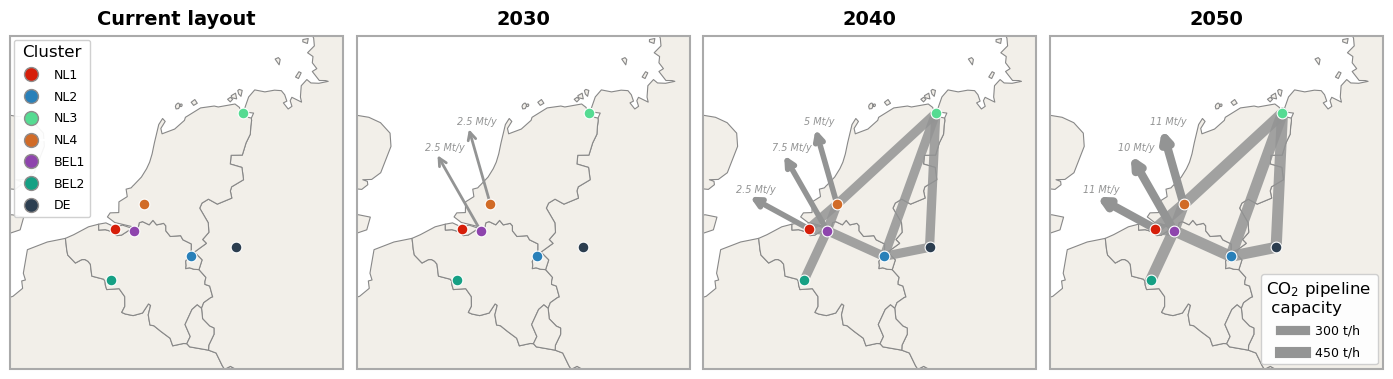

In [73]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Parametri ────────────────────────────────────────────────────────────────
XMIN, YMIN, XMAX, YMAX = 3_700_000, 2_900_000, 4_300_000, 3_500_000
CENTROID_MS = 120

CLUSTER_COLORS = {
    'NL1':  "#d61e09", 'NL2':  '#2980b9', 'NL3':  "#55db92",
    'NL4':  "#d16b27", 'BEL1': '#8e44ad', 'BEL2': "#16a084", 'DE': '#2c3e50',
}
CLUSTERS_ORDER = ['NL1', 'NL2', 'NL3', 'NL4', 'BEL1', 'BEL2', 'DE']

YEARS = [2025, 2030, 2040, 2050]

LINE_WIDTH_MIN = 0.5
LINE_WIDTH_MAX = 8.0
LINE_COLOR     = "#939494"   # arancio-rosso simile al plot di riferimento
LINE_ALPHA     = 0.85

PRODUCTS = ['Ammonia', 'Ethylene', 'Propylene', 'Methanol']

# ── Carica impianti e calcola centroidi cluster (stesso metodo del codice originale) ──
plants = pd.read_excel(
    "data/SFI_ALD_Petrochemicals_Sample_EU_NA_Apr_2022.xlsx",
    sheet_name="SFI_ALD_Petrochemicals_EUNA"
)
europe = plants[plants['region'] == 'Europe'].dropna(subset=['latitude', 'longitude']).copy()
mask_c  = europe['country'].isin(['Netherlands', 'Belgium', 'Luxembourg', 'Germany'])
mask_de = (europe['country'] == 'Germany') & (europe['state'] == 'North Rhine-Westphalia')
europe_filtered = europe[mask_c & ((europe['country'] != 'Germany') | mask_de)].copy()
europe_filtered = europe_filtered[europe_filtered['petrochemical'].isin(PRODUCTS)].copy()

cluster_coords = (
    europe_filtered.groupby('Cluster')[['latitude', 'longitude']].mean().reset_index()
)

# ── Converti centroidi in EPSG:3035 ──────────────────────────────────────────
gdf_clusters = gpd.GeoDataFrame(
    cluster_coords,
    geometry=gpd.points_from_xy(cluster_coords['longitude'], cluster_coords['latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:3035')
gdf_clusters['x'] = gdf_clusters.geometry.x
gdf_clusters['y'] = gdf_clusters.geometry.y

cluster_xy = dict(zip(gdf_clusters['Cluster'], zip(gdf_clusters['x'], gdf_clusters['y'])))


# ── Leggi existing_sizes per un anno ─────────────────────────────────────────
def load_existing_sizes(year):
    path = (
        f"case_studies/base_case_10_dd/{year}/networks/existing/"
        f"CO2_Pipeline.xlsx"
    )
    df = pd.read_excel(path, sheet_name='existing_sizes', index_col=0)
    return df   # matrice cluster×cluster


# ── Confini NUTS (stesso file dell'altro script) ──────────────────────────────
nuts      = gpd.read_file(r'data/NUTS_RG_20M_2016_3035.shp.zip')
countries = nuts[nuts['LEVL_CODE'] == 0].cx[XMIN:XMAX, YMIN:YMAX].copy()


# ── Calcola spessore linea ────────────────────────────────────────────────────
def line_width(val, max_val):
    if max_val == 0 or val == 0:
        return 0
    return LINE_WIDTH_MIN + (LINE_WIDTH_MAX - LINE_WIDTH_MIN) * np.sqrt(val / max_val)


# ── Raccoglie tutti i valori per normalizzare su tutti gli anni ───────────────
all_values = []
data_by_year = {}
for yr in YEARS:
    try:
        df = load_existing_sizes(yr)
        data_by_year[yr] = df
        # prendi solo il triangolo superiore (matrice simmetrica)
        for i, r in enumerate(df.index):
            for j, c in enumerate(df.columns):
                if j > i:
                    v = df.loc[r, c]
                    if v > 0:
                        all_values.append(v)
    except FileNotFoundError as e:
        print(f"[ATTENZIONE] File non trovato per {yr}: {e}")
        data_by_year[yr] = None

global_max = max(all_values) if all_values else 1


# ── Figura 1×4 ────────────────────────────────────────────────────────────────
plt.rcParams['font.size'] = 9
plt.rcParams['font.weight'] = 'normal'

fig, axes = plt.subplots(1, 4, figsize=(14, 14))
axes_flat = axes.flatten()

for idx, yr in enumerate(YEARS):
    ax = axes_flat[idx]
    df = data_by_year.get(yr)

    # Mappa di sfondo
    countries.plot(ax=ax, color='#f2efe9', edgecolor='#888888', linewidth=0.8)

    if df is not None:
        clusters_in_data = [c for c in df.index if c in cluster_xy]

        # ── Linee pipeline ────────────────────────────────────────────────────
        drawn_pairs = set()
        for r in clusters_in_data:
            for c in df.columns:
                if c not in cluster_xy:
                    continue
                if (r, c) in drawn_pairs or (c, r) in drawn_pairs:
                    continue
                val = df.loc[r, c]
                if val <= 0:
                    continue
                drawn_pairs.add((r, c))
                x0, y0 = cluster_xy[r]
                x1, y1 = cluster_xy[c]
                lw = line_width(val, global_max)
                ax.plot(
                    [x0, x1], [y0, y1],
                    color=LINE_COLOR, linewidth=lw,
                    alpha=LINE_ALPHA, solid_capstyle='round',
                    zorder=3
                )

        # ── Frecce export CO2 → North Sea (offshore storage) ─────────────────────
        # Capacità annuale da inserire a mano (Mt/y o t/h, come preferisci)
        if yr == 2030 or yr == 2040 or yr == 2050:

            if yr == 2030:
                OFFSHORE_EXPORT = {
                    'NL4':  {'cap': '2.5 Mt/y', 'dx': -40_000, 'dy':  140_000},
                    'BEL1': {'cap': '2.5 Mt/y', 'dx': -80_000, 'dy':  140_000},
                }
                lw = 2
            elif yr == 2040:
                OFFSHORE_EXPORT = {
                    'NL1': {'cap': '2.5 Mt/y', 'dx': -110_000, 'dy':  60_000},
                    'NL4':  {'cap': '5 Mt/y', 'dx': -40_000, 'dy':  140_000},
                    'BEL1': {'cap': '7.5 Mt/y', 'dx': -80_000, 'dy':  140_000},
                }
                lw = 4
            elif yr == 2050:
                OFFSHORE_EXPORT = {
                    'NL1': {'cap': '11 Mt/y', 'dx': -110_000, 'dy':  60_000},
                    'NL4':  {'cap': '11 Mt/y', 'dx': -40_000, 'dy':  140_000},
                    'BEL1': {'cap': '10 Mt/y', 'dx': -80_000, 'dy':  140_000},
                }
                lw = 6

            ARROW_COLOR = '#939494'

            for cl, cfg in OFFSHORE_EXPORT.items():
                if cl not in cluster_xy:
                    continue
                x0, y0 = cluster_xy[cl]
                x1 = x0 + cfg['dx']
                y1 = y0 + cfg['dy']
                ax.annotate(
                    '',                          # testo vuoto: solo la freccia
                    xy=(x1, y1),                 # punta della freccia
                    xytext=(x0, y0),             # coda (nodo cluster)
                    arrowprops=dict(
                        arrowstyle='->', 
                        color=ARROW_COLOR,
                        lw = lw,
                        mutation_scale=14,       # dimensione della punta
                    ),
                    zorder=4
                )
                # Label capacità vicino alla punta
                ax.text(
                    x1 - 20_000, y1 + 4_000,
                    cfg['cap'],
                    fontsize=7, color=ARROW_COLOR,
                    fontstyle='italic',
                    bbox=dict(facecolor='white', alpha=0.6,
                            edgecolor='none', boxstyle='round,pad=0.15'),
                    zorder=5
                )

        # ── Nodi cluster ──────────────────────────────────────────────────────
        for cl, (cx, cy) in cluster_xy.items():
            color = CLUSTER_COLORS.get(cl, '#555555')
            ax.scatter(cx, cy, marker='o', s=60,
                       color=color, edgecolors='white',
                       linewidths=0.8, zorder=6)
            # ax.annotate(
            #     cl, (cx, cy),
            #     xytext=(6, 6), textcoords='offset points',
            #     fontsize=9, fontweight='bold', color=color,
            #     fontstyle='italic', zorder=7,
            #     bbox=dict(facecolor='white', alpha=0.6,
            #               edgecolor='none', boxstyle='round,pad=0.1')
            # )

    # ── Titolo subplot ────────────────────────────────────────────────────────
    if yr == 2025:
        ax.set_title(f'Current layout', fontsize=14, fontweight='bold', pad=8)
    else:
        ax.set_title(f'{yr}', fontsize=14, fontweight='bold', pad=8)

    # ── Estetica ──────────────────────────────────────────────────────────────
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_axis_off()

    # Frame grigio
    ax.add_patch(mpatches.Rectangle(
        (0, 0), 1, 1, transform=ax.transAxes,
        fill=False, edgecolor='#aaaaaa', linewidth=1.5,
        zorder=10, clip_on=False
    ))


# ── Legenda globale (in basso al centro) ─────────────────────────────────────
clust_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=CLUSTER_COLORS[c], markeredgecolor='#8F8C8C',
           markersize=10, label=c)
    for c in CLUSTERS_ORDER if c in CLUSTER_COLORS
]

# Legenda spessore linee

sizes_legend = []
for frac in [0.666667, 1.0]:
    raw = global_max * frac                          # valore in t/h per line_width
    lw  = line_width(raw, global_max)
    cap_gw = raw                       # valore in GW per l'etichetta
    sizes_legend.append(
        Line2D([0], [0], color=LINE_COLOR, linewidth=lw, label=f'{cap_gw:.0f} t/h')
    )

fig.legend(
    handles=clust_handles,
    title='Cluster', title_fontsize=12,
    loc='lower left', bbox_to_anchor=(0.008, 0.525),
    fontsize=9, framealpha=0.92, edgecolor='#cccccc', labelspacing=0.7,
    ncol=1
)
fig.legend(
    handles=sizes_legend,
    title=f'CO$_2$ pipeline \n capacity', title_fontsize=12,
    loc='lower right', bbox_to_anchor=(0.991, 0.42),
    fontsize=9, framealpha=0.92, edgecolor='#cccccc', labelspacing=0.7,
    ncol=1
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('figure/co2_network_scenarios.png', dpi=600, bbox_inches='tight')
# print("Salvato: data/co2_network_scenarios.png")

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# --- dati ---
plants = pd.read_excel("data/SFI_ALD_Petrochemicals_Sample_EU_NA_Apr_2022.xlsx",
                       sheet_name="SFI_ALD_Petrochemicals_EUNA")
europe = plants[plants['region'] == 'Europe'].dropna(subset=['latitude','longitude']).copy()

gdf = gpd.GeoDataFrame(
    europe,
    geometry=gpd.points_from_xy(europe['longitude'], europe['latitude']),
    crs="EPSG:4326"
)

# --- base map: Natural Earth via URL (S3 mirror) ---
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# bounding box Europa approx (lon_min, lat_min, lon_max, lat_max)
bbox = (-25, 34, 45, 72)
world_eu = world.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
gdf_eu   = gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 10))
world_eu.plot(ax=ax, color="#f0f0f0", edgecolor="#999999", linewidth=0.5)
gdf_eu.plot(ax=ax, markersize=20, alpha=0.9)
ax.set_title("Impianti (Europa)")
ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()


In [ ]:
# Filter data on European plants for column 'country' == 'Netherlands', 'Belgium', 'Luxembourg' or 'Germany'
selected_countries = ['Netherlands', 'Belgium', 'Luxembourg', 'Germany']

# keep selected countries, and for Germany require state == 'North Rhine-Westphalia'
mask_countries = europe['country'].isin(selected_countries)
mask_germany_nrw = (europe['country'] == 'Germany') & ((europe['state'] == 'North Rhine-Westphalia'))
mask = mask_countries & ((europe['country'] != 'Germany') | mask_germany_nrw)
europe_filtered = europe[mask].copy()
chemicals = ['Ethylene', 'Propylene', 'Ammonia', 'Methanol']
mask_chemicals = europe_filtered['petrochemical'].isin(chemicals)
europe_filtered = europe_filtered[mask_chemicals].copy()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from shapely.geometry import Point
import numpy as np

# Filter data on European plants for column 'country' == 'Netherlands', 'Belgium', 'Luxembourg' or 'Germany'
selected_countries = ['Netherlands', 'Belgium', 'Luxembourg', 'Germany']

# keep selected countries, and for Germany require state == 'North Rhine-Westphalia'
mask_countries = europe['country'].isin(selected_countries)
mask_germany_nrw = (europe['country'] == 'Germany') & ((europe['state'] == 'North Rhine-Westphalia'))
mask = mask_countries & ((europe['country'] != 'Germany') | mask_germany_nrw)
europe_filtered = europe[mask].copy()
chemicals = ['Ethylene', 'Propylene', 'Ammonia', 'Methanol']
mask_chemicals = europe_filtered['petrochemical'].isin(chemicals)
europe_filtered = europe_filtered[mask_chemicals].copy()

prodotti = ['Ammonia', 'Ethylene', 'Propylene', 'Methanol']
clusters = ['NL1', 'NL2', 'NL3', 'NL4', 'BEL1', 'BEL2', 'DE']
europe_filtered_by_product = europe_filtered[europe_filtered['petrochemical'].isin(prodotti)].copy()
europe_filtered_by_cluster = europe_filtered[europe_filtered['Cluster'].isin(clusters)].copy()

colori = {
    'Ammonia':   '#e74c3c',
    'Ethylene':  '#3498db',
    'Propylene': '#2ecc71',
    'Methanol':  '#f39c12',
}

colors_for_clusters = {
    'NL1': '#e74c3c',
    'NL2': '#3498db',
    'NL3': '#2ecc71',
    'NL4': '#f39c12',
    'BEL1': '#9b59b6',
    'BEL2': '#1abc9c',
    'DE': '#34495e',
}

# Converti in GeoDataFrame e reproietta in EPSG:3035
gdf_plants = gpd.GeoDataFrame(
    europe_filtered_by_product,
    geometry=[Point(lon, lat) for lon, lat in zip(europe_filtered_by_product['longitude'], europe_filtered_by_product['latitude'])],
    crs='EPSG:4326'
).to_crs('EPSG:3035')

gdf_plants['x'] = gdf_plants.geometry.x
gdf_plants['y'] = gdf_plants.geometry.y

# --- Carica i confini NUTS livello 0 ---
nuts = gpd.read_file(r'data\NUTS_RG_20M_2016_3035.shp.zip')
countries = nuts[nuts['LEVL_CODE'] == 0].copy()

xmin, ymin, xmax, ymax = 3_700_000, 2_900_000, 4_300_000, 3_500_000
countries = countries.cx[xmin:xmax, ymin:ymax]

# --- Figura ---
fig, ax = plt.subplots(figsize=(12, 10))

countries.plot(
    ax=ax,
    color='#f0ede8',
    edgecolor='#aaaaaa',
    linewidth=0.5
)

# --- Disegna gli spicchi ---
# Raggruppa per posizione esatta (stesso impianto, prodotti diversi)
RADIUS = 7500  # raggio in metri (EPSG:3035); regola a piacere

for (x, y), group in gdf_plants.groupby(['x', 'y']):
    prods = group['petrochemical'].tolist()
    n = len(prods)
    angle_step = 360 / n
    start_angle = 90  # parte dall'alto, gira in senso antiorario

    for prod in prods:
        wedge = Wedge(
            center=(x, y),
            r=RADIUS,
            theta1=start_angle - angle_step,
            theta2=start_angle,
            facecolor=colori[prod],
            edgecolor='white',
            linewidth=0.6,
            zorder=3
        )
        ax.add_patch(wedge)
        start_angle -= angle_step

# --- Legenda manuale ---
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(facecolor=colori[p], edgecolor='white', label=p)
    for p in prodotti
]
ax.legend(
    handles=legend_handles,
    title='Product',
    title_fontsize=11,
    fontsize=10,
    loc='lower left',
    framealpha=0.9
)

# --- Estetica ---
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('Petrochemical plants by product', fontsize=15, fontweight='bold', pad=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('data/plants_map.png', dpi=150, bbox_inches='tight')
print("Mappa salvata come 'plants_map.png'")

# --- Plot con cluster ---
fig, ax = plt.subplots(figsize=(12, 10))
countries.plot(
    ax=ax,
    color='#f0ede8',
    edgecolor='#aaaaaa',
    linewidth=0.5
)
for (x, y), group in gdf_plants.groupby(['x', 'y']):
    cluster = group['Cluster'].iloc[0]  # assumiamo che tutti i prodotti dello stesso impianto appartengano allo stesso cluster
    color = colors_for_clusters.get(cluster, '#000000')  # nero se cluster sconosciuto
    circle = plt.Circle((x, y), RADIUS/2, color=color, alpha=0.8, edgecolor='white', linewidth=0.6, zorder=3)
    ax.add_patch(circle)
legend_handles = [
    mpatches.Patch(facecolor=colors_for_clusters[c], edgecolor='white',
                        label=c) for c in clusters  ]
ax.legend(
    handles=legend_handles,
    title='Cluster',
    title_fontsize=11,
    fontsize=10,
    loc='lower left',
    framealpha=0.9
)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('Petrochemical plants by cluster', fontsize=15, fontweight='bold', pad=14)
ax.set_axis_off()
plt.tight_layout()
# plt.savefig('data/plants_map_clusters.png', dpi=150, bbox_inches='tight')
print("Mappa salvata come 'plants_map_clusters.png'")


In [ ]:
# pip install geopandas shapely matplotlib
import geopandas as gpd
import matplotlib.pyplot as plt

df = europe_filtered.dropna(subset=["latitude","longitude"]).copy()
# assicurati che 'petrochemical' sia di tipo categorico
df["petrochemical"] = df["petrochemical"].fillna("Unknown").astype("category")
# assicurati che 'cluster' sia di tipo categorico
df["Cluster"] = df["Cluster"].fillna("Unknown").astype("category")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Base map Natural Earth
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# ROI: Benelux + NRW (lon_min, lat_min, lon_max, lat_max)
bbox = (2.0, 49.0, 9.5, 54.0)
world_roi = world.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
gdf_roi   = gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

fig, ax = plt.subplots(figsize=(8, 9))
world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

# colore per categoria: usa direttamente la colonna
gdf_roi.plot(
    ax=ax,
    column="Cluster",
    categorical=True,
    legend=True,
    markersize=35,
    alpha=0.9
)

ax.set_title("Impianti filtrati", fontsize=12)
ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()



In [ ]:
# Filter columns that we need
europe_filtered = europe_filtered[[
    'uid', 'country','latitude', 'longitude',
    'petrochemical', 'capacity', 'Cluster'
]]
# add column 'altitude' with value 0 for all rows
europe_filtered['altitude'] = 0

Cluster plants as unified units according to Cluter column

In [ ]:
rows = []

for cluster in europe_filtered['Cluster'].unique():
    cluster_data = europe_filtered[europe_filtered['Cluster'] == cluster]
    latitude = round(cluster_data['latitude'].mean(), 6) # crop to 6 decimals
    longitude = round(cluster_data['longitude'].mean(), 6) # crop to 6 decimals
    altitude = round(cluster_data['altitude'].mean(), 1) # crop to 1 decimal

    ammonia_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Ammonia', 'capacity'].sum()
    ethylene_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Ethylene', 'capacity'].sum()
    propylene_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Propylene', 'capacity'].sum()
    methanol_capacity = cluster_data.loc[cluster_data['petrochemical'] == 'Methanol', 'capacity'].sum()

    rows.append({
        'cluster': cluster,
        'country': cluster_data['country'].mode()[0],
        'latitude': latitude,
        'longitude': longitude,
        'altitude': altitude,
        'ammonia': ammonia_capacity,
        'ethylene': ethylene_capacity,
        'propylene': propylene_capacity,
        'methanol': methanol_capacity
    })

cluster_df = pd.DataFrame(rows, columns=['cluster', 'country', 'latitude', 'longitude', 'altitude', 'ammonia', 'ethylene', 'propylene', 'methanol'])

# save results to CSV
cluster_df.to_csv("data/plants_clusters_summary.csv", index=False)

In [ ]:
import numpy as np
import pandas as pd

# Average radius of the Earth in kilometers
EARTH_RADIUS_KM = 6371.0088

def pairwise_haversine(lat, lon, radius_km=EARTH_RADIUS_KM):
    """
    Calculate the matrix of pairwise Haversine distances between points.
    lat, lon: arrays of shape (N,) with latitude and longitude in degrees.
    Returns: array (N, N) with distances in km (diagonal = 0).
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    # in radianti
    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    # broadcasting
    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]

    a = np.sin(dlat/2.0)**2 + np.cos(lat_rad)[:, None] * np.cos(lat_rad)[None, :] * np.sin(dlon/2.0)**2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

    return radius_km * c


def distance_matrix(locations):
    """
    locations: DataFrame with columns [uid, latitude, longitude]
    Returns:

    """
    lat = locations["latitude"].to_numpy()
    lon = locations["longitude"].to_numpy()
    D = pairwise_haversine(lat, lon)
    idx = locations.index

    return pd.DataFrame(D, index=idx, columns=idx)


# Data
df = pd.read_csv("data/plants_clusters_summary.csv")[['cluster','latitude','longitude']].set_index('cluster')
distance_df = distance_matrix(df)   # DataFrame NxN con etichette
# convert to int
distance_df = distance_df.round().astype(int)
print(distance_df)

# Save to CSV
distance_df.to_csv("data/plants_distance_matrix.csv", sep=';')